In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
#load the dataset
df = pd.read_csv('data/nz_beef_exports.csv')



In [4]:
#show the first 5 rows of the dataframe
df.head()


,Year ended June,Series,Sector,Sub-sector,Measure,Value,Value Unit,Value Label,Null Reason,Metadata 1,Metadata 2
0,2004,Actual,Dairy,Whole milk powder,Export volume,660359.0,number,Tonnes,NaN,NaN,NaN
1,2005,Actual,Dairy,Whole milk powder,Export volume,578231.0,number,Tonnes,NaN,NaN,NaN
2,2006,Actual,Dairy,Whole milk powder,Export volume,643853.0,number,Tonnes,NaN,NaN,NaN
3,2007,Actual,Dairy,Whole milk powder,Export volume,652448.0,number,Tonnes,NaN,NaN,NaN
4,2008,Actual,Dairy,Whole milk powder,Export volume,632411.0,number,Tonnes,NaN,NaN,NaN


In [5]:
#Show the column names, data types & total entries
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964 entries, 0 to 2963
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year ended June  2964 non-null   int64  
 1   Series           2964 non-null   object 
 2   Sector           2964 non-null   object 
 3   Sub-sector       2964 non-null   object 
 4   Measure          2964 non-null   object 
 5   Value            2964 non-null   float64
 6   Value Unit       2964 non-null   object 
 7   Value Label      2964 non-null   object 
 8   Null Reason      0 non-null      float64
 9   Metadata 1       780 non-null    object 
 10  Metadata 2       104 non-null    object 
dtypes: float64(2), int64(1), object(8)
memory usage: 254.8+ KB


In [6]:
#show the number of rows and columns
df.count()

Year ended June    2964
Series             2964
Sector             2964
Sub-sector         2964
Measure            2964
Value              2964
Value Unit         2964
Value Label        2964
Null Reason           0
Metadata 1          780
Metadata 2          104
dtype: int64

In [7]:
#show the data types of each column
df.dtypes

Year ended June      int64
Series              object
Sector              object
Sub-sector          object
Measure             object
Value              float64
Value Unit          object
Value Label         object
Null Reason        float64
Metadata 1          object
Metadata 2          object
dtype: object

In [8]:
#show the summary statistics of the numerical columns
df.describe()

,Year ended June,Value,Null Reason
count,2964.000000,2.964000e+03,0.0
mean,2016.500000,5.802747e+04,NaN
std,7.501266,1.607930e+05,NaN
min,2004.000000,6.000000e-01,NaN
25%,2010.000000,1.900000e+02,NaN
50%,2016.500000,8.100000e+02,NaN
75%,2023.000000,9.591500e+03,NaN
max,2029.000000,1.635410e+06,NaN


In [9]:
#check for missing values
df.isnull().sum()

Year ended June       0
Series                0
Sector                0
Sub-sector            0
Measure               0
Value                 0
Value Unit            0
Value Label           0
Null Reason        2964
Metadata 1         2184
Metadata 2         2860
dtype: int64

In [10]:
#convert nan values to 0
# df.fillna(0, inplace=True)

In [11]:
# Keep only columns where NOT ALL values are 0
df = df.loc[:, (df != 0).any(axis=0)]

In [12]:
# Remove any column that is 100% empty
df.dropna(axis=1,inplace=True)


In [13]:
# Then check the difference in size
print(f"Original: {len(df)}")

Original: 2964


In [14]:
# This tells pandas: "Don't limit the rows, show me everything."
pd.set_option('display.max_rows', None)

# If your columns are also getting hidden, use this too:
#pd.set_option('display.max_columns', None)

df.head(5)

,Year ended June,Series,Sector,Sub-sector,Measure,Value,Value Unit,Value Label
0,2004,Actual,Dairy,Whole milk powder,Export volume,660359.0,number,Tonnes
1,2005,Actual,Dairy,Whole milk powder,Export volume,578231.0,number,Tonnes
2,2006,Actual,Dairy,Whole milk powder,Export volume,643853.0,number,Tonnes
3,2007,Actual,Dairy,Whole milk powder,Export volume,652448.0,number,Tonnes
4,2008,Actual,Dairy,Whole milk powder,Export volume,632411.0,number,Tonnes


In [15]:
#change data types of column Value to int
df['Value'] = df['Value'].astype(int)
df.dtypes

Year ended June     int64
Series             object
Sector             object
Sub-sector         object
Measure            object
Value               int64
Value Unit         object
Value Label        object
dtype: object

In [16]:
#To see the Currency Labels of all Values in dataset.
df['Value Label'].unique()

array(['Tonnes', 'NZD per tonne', 'NZD millions', 'Tonnes (gross)',
       'NZD per tonne (gross)', 'NZD per kilogram',
       'NZD per kilogram (gross)', 'Thousand litres', 'NZD per litre',
       'Thousand cubic metres', 'NZD per cubic metre',
       'Thousand tonnes (gross)', 'Thousand bone dry units (BDU)',
       'NZD per bone dry unit (BDU)', 'Thousands cubic tonnes (gross)'],
      dtype=object)

In [17]:
#to check how many unique values are in the column 'Value Label'
df['Value Label'].nunique()

15

In [18]:
#to chech the frequency of each unique value in the column 'Value Label'
df['Value Label'].value_counts()

Value Label
NZD millions                      1300
Tonnes                             520
NZD per kilogram                   364
NZD per tonne                      182
Tonnes (gross)                     104
NZD per tonne (gross)               78
NZD per kilogram (gross)            78
Thousand cubic metres               78
NZD per cubic metre                 78
Thousand tonnes (gross)             52
Thousand litres                     26
NZD per litre                       26
Thousand bone dry units (BDU)       26
NZD per bone dry unit (BDU)         26
Thousands cubic tonnes (gross)      26
Name: count, dtype: int64

In [19]:
#check the unique values in the column 'Sector'
df['Sector'].unique()

array(['Dairy', 'Meat & wool', 'Forestry', 'Horticulture', 'Seafood',
       'Arable', 'Other primary sector'], dtype=object)

In [20]:
#check the unique values in the column Sub-sector
df['Sub-sector'].unique()

array(['Whole milk powder', 'Butter, AMF, and cream',
       'Skim milk & butter milk powder', 'Casein & protein products',
       'Cheese', 'Infant formula', 'Fluid milk and other dairy products',
       'Total', 'Beef & veal', 'Lamb', 'Mutton', 'Wool', 'Venison',
       'Other meat', 'Hides & skins', 'Animal co-products',
       'Animal fats & oils', 'Animal products for feed',
       'Carpets & other wool products', 'Kiwifruit', 'Wine',
       'Apples & pears', 'Fresh & processed vegetables',
       'Other horticultural products', 'Logs', 'Sawn timber & sleepers',
       'Pulp', 'Paper & paperboard', 'Panels', 'Wood chips',
       'Other forestry products', 'Wild capture', 'Aquaculture',
       'Vegetable seed', 'Ryegrass seed', 'Clover/legume seed',
       'Other grains & seeds', 'Innovative processed foods',
       'Sugar & confectionery', 'Honey', 'Cereal products',
       'Live animals', 'Soups & condiments', 'Other products'],
      dtype=object)

In [21]:
#check the unique values in the column Series
df['Series'].unique()

array(['Actual', 'Forecast'], dtype=object)

In [22]:
#check the unique values in the column Measure
df['Measure'].unique()

array(['Export volume', 'Average export price', 'Export revenue'],
      dtype=object)

In [23]:
#check which sectors have the highest export values
export_by_sector = df.groupby('Sector')['Value'].sum().sort_values(ascending=False)
export_by_sector

Sector
Dairy                   79769394
Forestry                42473749
Meat & wool             41944000
Seafood                  7310892
Horticulture              353539
Other primary sector      129825
Arable                     11791
Name: Value, dtype: int64

In [24]:
df.head()

,Year ended June,Series,Sector,Sub-sector,Measure,Value,Value Unit,Value Label
0,2004,Actual,Dairy,Whole milk powder,Export volume,660359,number,Tonnes
1,2005,Actual,Dairy,Whole milk powder,Export volume,578231,number,Tonnes
2,2006,Actual,Dairy,Whole milk powder,Export volume,643853,number,Tonnes
3,2007,Actual,Dairy,Whole milk powder,Export volume,652448,number,Tonnes
4,2008,Actual,Dairy,Whole milk powder,Export volume,632411,number,Tonnes


In [25]:
#check which subsector under the sector Meat & wool has the highest export values in btween 2004 and 2026  
meat_wool_exports = df[(df['Sector'] == 'Meat & wool') & (df['Year ended June'] >= 2004) & (df['Year ended June'] <= 2026)]
meat_wool_exports_by_subsector = meat_wool_exports.groupby('Sub-sector')['Value'].sum().sort_values(ascending=False)
meat_wool_exports_by_subsector 

Sub-sector
Beef & veal                      9658387
Lamb                             6976198
Animal products for feed         4255516
Animal fats & oils               3130857
Animal co-products               2768475
Wool                             2739985
Hides & skins                    2687148
Other meat                       2099756
Mutton                           1806146
Carpets & other wool products     400978
Venison                           371965
Total                             208629
Name: Value, dtype: int64

In [26]:
#check the average export price(which is a column value of column Measure) per Value for each subsector under the sector Meat & wool    
meat_wool_exports_price = meat_wool_exports[meat_wool_exports['Measure'] == 'Average export price']
meat_wool_exports_price_by_subsector = meat_wool_exports_price.groupby('Sub-sector')['Value'].mean().sort_values(ascending=False)
meat_wool_exports_price_by_subsector

Sub-sector
Venison                          12.521739
Carpets & other wool products    10.434783
Lamb                              8.695652
Beef & veal                       6.304348
Mutton                            5.260870
Other meat                        4.782609
Animal co-products                4.608696
Wool                              4.521739
Hides & skins                     3.391304
Animal products for feed          1.173913
Animal fats & oils                0.782609
Name: Value, dtype: float64

In [27]:
#Convert Value label column into a NumPy array using .to_numpy() for faster processing and analysis.
value_labels_array = df['Value Label'].to_numpy()

# 1. Access the name of the column directly
print(f"The column name is: {df['Value Label'].name}")

# 2. Check the difference in "Shape"
print(f"Pandas Shape: {df['Value Label'].shape}")
print(f"NumPy Shape: {value_labels_array.shape}")


The column name is: Value Label
Pandas Shape: (2964,)
NumPy Shape: (2964,)


In [28]:
df.head()

,Year ended June,Series,Sector,Sub-sector,Measure,Value,Value Unit,Value Label
0,2004,Actual,Dairy,Whole milk powder,Export volume,660359,number,Tonnes
1,2005,Actual,Dairy,Whole milk powder,Export volume,578231,number,Tonnes
2,2006,Actual,Dairy,Whole milk powder,Export volume,643853,number,Tonnes
3,2007,Actual,Dairy,Whole milk powder,Export volume,652448,number,Tonnes
4,2008,Actual,Dairy,Whole milk powder,Export volume,632411,number,Tonnes


In [29]:
# df['Sub-sector'].unique()
# Create a dedicated dataframe for Meat & wool
meat_wool_df = df[df['Sector'] == 'Meat & wool'].copy()

# Further narrow it down to just 'Beef' if that is your main goal
# Check your 'Sub-sector' column for the exact spelling
beef_df = meat_wool_df[meat_wool_df['Sub-sector'] == 'Beef & veal'].copy()
beef_df.head()


,Year ended June,Series,Sector,Sub-sector,Measure,Value,Value Unit,Value Label
572,2004,Actual,Meat & wool,Beef & veal,Export volume,414041,number,Tonnes
573,2005,Actual,Meat & wool,Beef & veal,Export volume,399832,number,Tonnes
574,2006,Actual,Meat & wool,Beef & veal,Export volume,378093,number,Tonnes
575,2007,Actual,Meat & wool,Beef & veal,Export volume,357410,number,Tonnes
576,2008,Actual,Meat & wool,Beef & veal,Export volume,357209,number,Tonnes


In [30]:
# This calculates the KPI stats across ALL years combined
overall_beef_stats = beef_df['Value'].agg(['mean', 'median', 'std', 'var', 'min', 'max'])
print("Beef Export Statistics (2004-2024):")
print(overall_beef_stats)

Beef Export Statistics (2004-2024):
mean      1.428102e+05
median    2.961500e+03
std       2.034371e+05
var       4.138665e+10
min       4.000000e+00
max       5.090310e+05
Name: Value, dtype: float64


In [31]:
# Compare the average export volume of different meat types
sector_comparison = meat_wool_df.groupby('Sub-sector')['Value'].mean().sort_values(ascending=False)
print(sector_comparison)

Sub-sector
Beef & veal                      142810.217949
Lamb                             100593.384615
Animal products for feed          62300.192308
Animal fats & oils                43955.551282
Animal co-products                39727.051282
Hides & skins                     39404.153846
Wool                              38520.000000
Other meat                        30477.294872
Mutton                            26114.064103
Total                              9512.269231
Carpets & other wool products      5481.333333
Venison                            5189.589744
Name: Value, dtype: float64


In [32]:
# Outlier Detection using IQR method for the 'Value' column in beef_df
# 1. Convert KPI to a NumPy array
values = beef_df['Value'].to_numpy()

# 2. Calculate Q1 (25th) and Q3 (75th)
q1 = np.percentile(values, 25)
q3 = np.percentile(values, 75)

# 3. Calculate IQR 
iqr = q3 - q1

# 4. Define bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

# 5. Identify Outliers
iqr_outliers = beef_df[(beef_df['Value'] < lower_bound) | (beef_df['Value'] > upper_bound)]
print(f"IQR Outliers found: {len(iqr_outliers)}")

IQR Outliers found: 0


In [33]:
# Outlier Detection using 3-Sigma method for the 'Value' column in beef_df
# Calculate Mean and Std Dev using NumPy
mean_val = np.mean(values)
std_val = np.std(values)

# Define the "Normal" Range
upper_3sigma = mean_val + (3 * std_val)
lower_3sigma = mean_val - (3 * std_val)

# Filter for anything outside that range
sigma_outliers = beef_df[(beef_df['Value'] > upper_3sigma) | (beef_df['Value'] < lower_3sigma)]
print(f"3-Sigma Outliers: {len(sigma_outliers)}")

3-Sigma Outliers: 0


In [34]:
# Correlation Analysis between Year and Value for Beef Exports
# 1. Prepare the two variables as NumPy arrays
years = beef_df['Year ended June'].to_numpy()
values = beef_df['Value'].to_numpy()

# 2. Calculate the correlation matrix using NumPy's corrcoef function
correlation_matrix = np.corrcoef(years, values)

# 3. Pull out the specific relationship value
# [0, 1] picks the intersection of Year and Value
r_value = correlation_matrix[0, 1]

print(f"Correlation Coefficient (r): {r_value:.4f}")

Correlation Coefficient (r): 0.0784


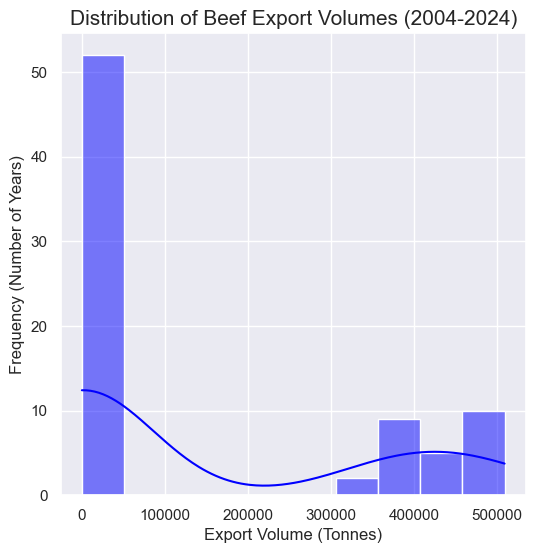

In [35]:
# Exploratory Visualization: Distribution of Beef Export Volumes
# Set the visual style
sns.set_theme(style="darkgrid")

# Create the plot
plt.figure(figsize=(6, 6))
sns.histplot(data=beef_df, x='Value', kde=True, color='blue', bins=10, )

# Add titles and labels
plt.title('Distribution of Beef Export Volumes (2004-2024)', fontsize=15)
plt.xlabel('Export Volume (Tonnes)', fontsize=12)
plt.ylabel('Frequency (Number of Years)', fontsize=12)

plt.show()

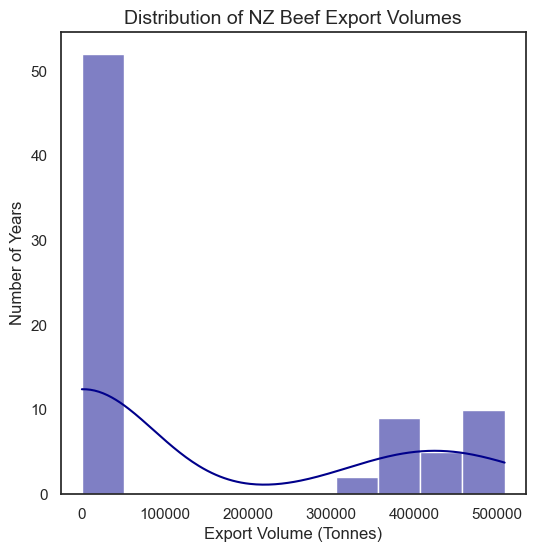

In [36]:
#Histogram + KDE for Beef Export Volumes with a more polished style and clear labels
# 1. Set a clean visual style
sns.set_theme(style="white")

# 2. Create the plot
plt.figure(figsize=(6, 6))
sns.histplot(data=beef_df, x='Value', kde=True, color='darkblue', bins=10)

# 3. Add clear labels for your portfolio
plt.title('Distribution of NZ Beef Export Volumes', fontsize=14)
plt.xlabel('Export Volume (Tonnes)', fontsize=12)
plt.ylabel('Number of Years', fontsize=12)

plt.show()

C:\Users\jsing\AppData\Local\Temp\ipykernel_15260\1021561428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=meat_wool_df, x='Sub-sector', y='Value', palette='Set2')


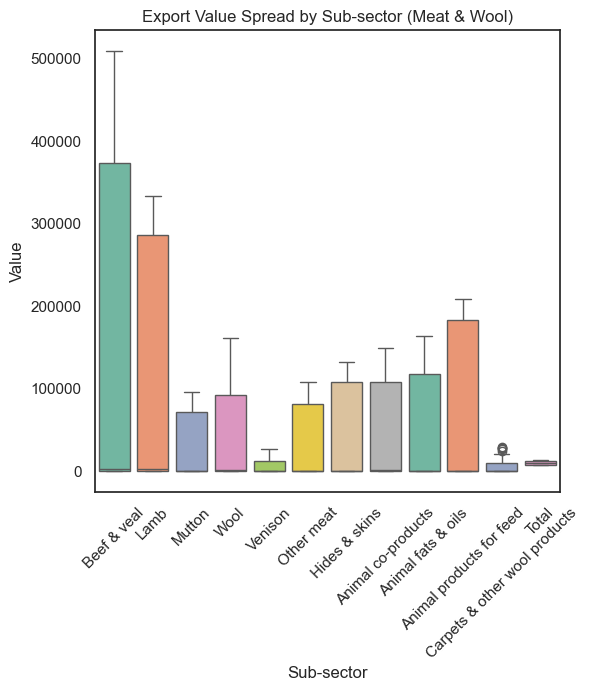

In [37]:
# Categorical Analysis: The "Performance Comparison" with a boxplot to show the spread of export values across different sub-sectors under Meat & wool
plt.figure(figsize=(6, 6))
sns.boxplot(data=meat_wool_df, x='Sub-sector', y='Value', palette='Set2')
plt.title('Export Value Spread by Sub-sector (Meat & Wool)')
plt.xticks(rotation=45)
plt.show()

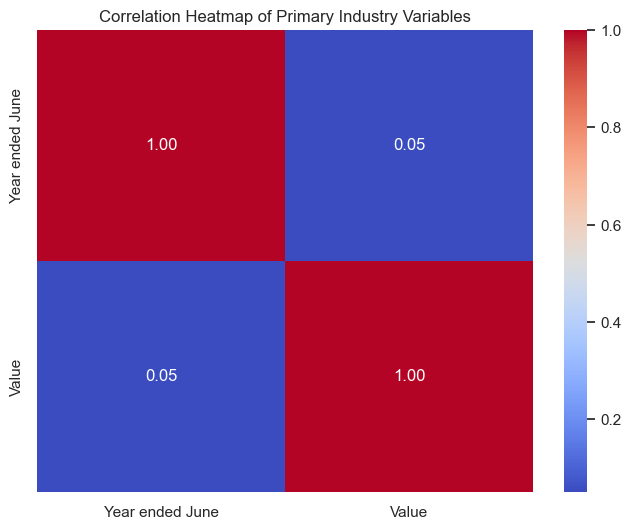

In [38]:
# Correlation Heatmap for Primary Industry Variables
plt.figure(figsize=(8, 6))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Primary Industry Variables')
plt.show()

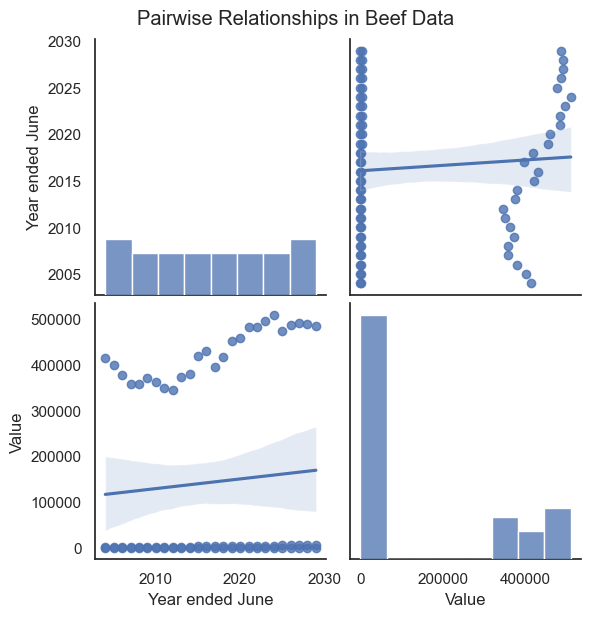

In [39]:
# Pairwise Relationships: Scatterplot Matrix for Year vs Value in Beef Exports
# Select only the columns you want to compare
sns.pairplot(beef_df[['Year ended June', 'Value']], kind='reg', height=3)
plt.suptitle('Pairwise Relationships in Beef Data', y=1.02)
plt.show()

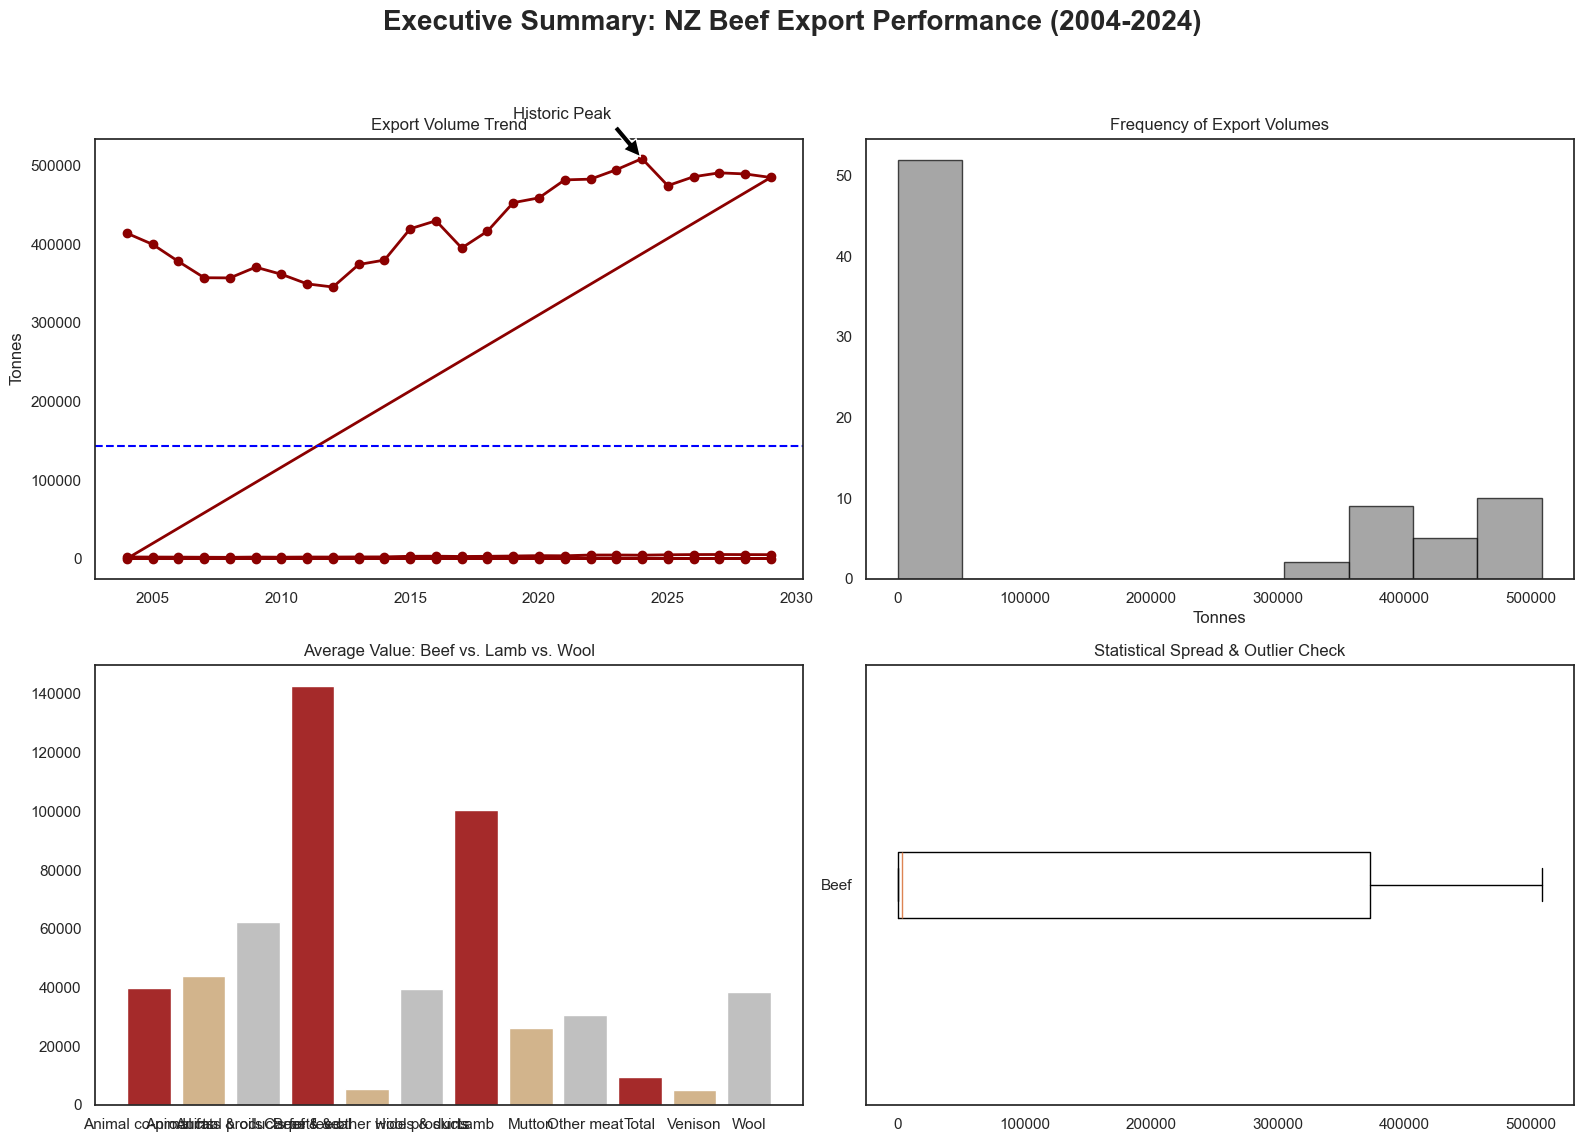

In [40]:
# Dashboard Creation: A 2x2 Layout for Key Visuals

# 1. Setup the 2x2 Layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Executive Summary: NZ Beef Export Performance (2004-2024)', fontsize=20, fontweight='bold')

# --- CHART 1: LINE CHART (Top Left) ---
axes[0, 0].plot(beef_df['Year ended June'], beef_df['Value'], marker='o', color='darkred', linewidth=2)
axes[0, 0].set_title('Export Volume Trend')
axes[0, 0].set_ylabel('Tonnes')

# Add a Mean Line
mean_val = beef_df['Value'].mean()
axes[0, 0].axhline(mean_val, color='blue', linestyle='--', label=f'Average: {mean_val:.0f}')

# ANNOTATION: Point to the highest year
max_year = beef_df.loc[beef_df['Value'].idxmax(), 'Year ended June']
max_val = beef_df['Value'].max()
axes[0, 0].annotate('Historic Peak', xy=(max_year, max_val), xytext=(max_year-5, max_val+50000),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- CHART 2: DISTRIBUTION (Top Right) ---
axes[0, 1].hist(beef_df['Value'], bins=10, color='gray', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Frequency of Export Volumes')
axes[0, 1].set_xlabel('Tonnes')

# --- CHART 3: SECTOR COMPARISON (Bottom Left) ---
# Assuming you have meat_wool_df ready
comparison = meat_wool_df.groupby('Sub-sector')['Value'].mean()
axes[1, 0].bar(comparison.index, comparison.values, color=['brown', 'tan', 'silver'])
axes[1, 0].set_title('Average Value: Beef vs. Lamb vs. Wool')

# --- CHART 4: VOLATILITY BOXPLOT (Bottom Right) ---
axes[1, 1].boxplot(beef_df['Value'], vert=False)
axes[1, 1].set_title('Statistical Spread & Outlier Check')
axes[1, 1].set_yticklabels(['Beef'])

# 2. Final Styling Polish
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to make room for the big title

# 3. Export as High-Res PNG
plt.savefig('beef_export_dashboard.png', dpi=300)
plt.show()